# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models? We use general linear models in analysis because it aids to nonlinear relationship and probabilites. The advantage they have over linear models is they keep the probablities between 0 and 1 which is better for interpretebility.
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models. They are effective because it helps assign the likelihood for the binary and categorical ouptputs.
3. True or false, and explain: Logistic regression is a linear model. True, because a logistic regression is linear in terms of the latent score
4. True or false, and explain: Logistic regression cannot be used for classification. False, because it predicts probabilities for the classifications
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable? No, a logisitic regression coefficient represents change of log-odds. This keep the other variables constant except for the feature.
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model. False, because a logistic model ends up being put through a sigmoid tranformation which is why it seems nonlinear, but before the tranformation it is linear.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead. False, because a logistic regression is generally better for binary and categorical values, not necessary continuous values.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [98]:
import pandas as pd

df = pd.read_csv("datasets/data.csv", sep=";")
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [99]:
#part 1
cols = ["Debtor", "Tuition fees up to date", "Scholarship holder", "Age at enrollment", "Curricular units 1st sem (approved)", "Target"]
df = df[cols]
df["Target"] = (df["Target"] == "Dropout").astype(int)
df = df.dropna()

In [100]:
#part 2
import statsmodels.api as sm
X = df[["Debtor", "Tuition fees up to date", "Scholarship holder", "Age at enrollment"]]
X = sm.add_constant(X)
y = df["Target"]
model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.500966
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 Target   No. Observations:                 4424
Model:                          Logit   Df Residuals:                     4419
Method:                           MLE   Df Model:                            4
Date:                Tue, 28 Apr 2026   Pseudo R-squ.:                  0.2020
Time:                        23:32:50   Log-Likelihood:                -2216.3
converged:                       True   LL-Null:                       -2777.3
Covariance Type:            nonrobust   LLR p-value:                1.298e-241
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       0.5352      0.182      2.943      0.003       0.179   

Debtor predicts higher dropout probability
Yes, tuition being up to date reduces dropout probability.

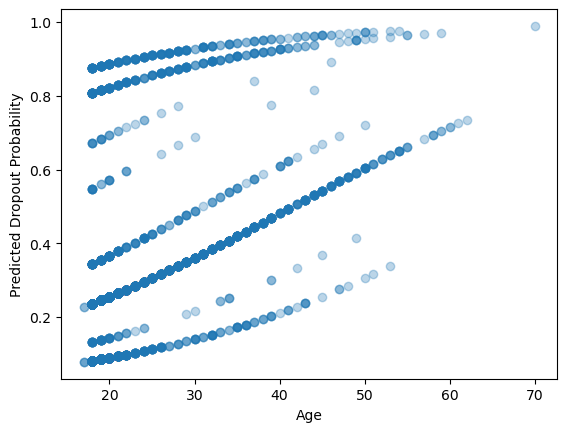

In [101]:
#part 3
import matplotlib.pyplot as plt
df["pred"] = model.predict(X)
plt.scatter(df["Age at enrollment"], df["pred"], alpha=0.3)
plt.xlabel("Age")
plt.ylabel("Predicted Dropout Probability")
plt.show()

Tuition up to date lowers dropout probability throughout all the ages
The dropout probability increases with age

In [102]:
#part 4
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = (df["pred"] > 0.5).astype(int)
print(confusion_matrix(y, y_pred))
print(accuracy_score(y, y_pred))

[[2841  162]
 [ 891  530]]
0.7619801084990958


accuracy is 76 percent

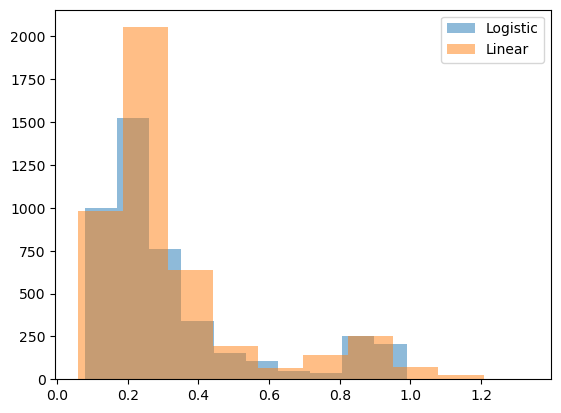

In [103]:
#part 5
from sklearn.linear_model import LinearRegression
lin = LinearRegression()
lin.fit(X, y)
df["lin_pred"] = lin.predict(X)
plt.hist(df["pred"], alpha=0.5, label="Logistic")
plt.hist(df["lin_pred"], alpha=0.5, label="Linear")
plt.legend()
plt.show()

logistic model is better since it keeps values between 0 and 1 rather than the linear which gives values higher than 1

#### Part 6

Students who are debtors are the most at-risk for dropping out.

In [104]:
#Part 7
import statsmodels.api as sm
X = df[["Debtor", "Tuition fees up to date", "Curricular units 1st sem (approved)"]]
X = sm.add_constant(X)
y_multi = pd.read_csv("datasets/data.csv", sep=";")["Target"]
model_multi = sm.MNLogit(y_multi, X).fit()
print(model_multi.summary())

Optimization terminated successfully.
         Current function value: 0.774337
         Iterations 7
                          MNLogit Regression Results                          
Dep. Variable:                 Target   No. Observations:                 4424
Model:                        MNLogit   Df Residuals:                     4416
Method:                           MLE   Df Model:                            6
Date:                Tue, 28 Apr 2026   Pseudo R-squ.:                  0.2407
Time:                        23:32:51   Log-Likelihood:                -3425.7
converged:                       True   LL-Null:                       -4511.8
Covariance Type:            nonrobust   LLR p-value:                     0.000
                    Target=Enrolled       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                                  -3.1610      0.194 

The model predicts dropout and graduate. The model doesn't predict all the classes, only the major ones, not the all. Despite all of that, the model still produces probablities of all the classes.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

In [105]:
#part 1
df2 = pd.read_csv("datasets/cirrhosis.csv")
cols = ["Bilirubin", "Edema", "Drug", "Stage", "Status"]
df2 = df2[cols]
df2 = df2.dropna()
df2["Status"] = df2["Status"].isin(["C", "CL"]).astype(int)
df2

,Bilirubin,Edema,Drug,Stage,Status
0,14.5,Y,D-penicillamine,4.0,0
1,1.1,N,D-penicillamine,3.0,1
2,1.4,S,D-penicillamine,4.0,0
3,1.8,S,D-penicillamine,4.0,0
4,3.4,N,Placebo,3.0,1
...,...,...,...,...,...
307,0.4,N,D-penicillamine,2.0,1
308,0.4,N,Placebo,2.0,1
309,1.7,N,D-penicillamine,2.0,1
310,2.0,N,D-penicillamine,2.0,1


In [106]:
# part 2
X = pd.get_dummies(df2[["Edema", "Drug", "Bilirubin"]], drop_first=True)
X = X.astype(float)
X = sm.add_constant(X)
y = df2["Status"].astype(float)
model2 = sm.Logit(y, X).fit()
print(model2.summary())

Optimization terminated successfully.
         Current function value: 0.530596
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                 Status   No. Observations:                  312
Model:                          Logit   Df Residuals:                      307
Method:                           MLE   Df Model:                            4
Date:                Tue, 28 Apr 2026   Pseudo R-squ.:                  0.2119
Time:                        23:32:51   Log-Likelihood:                -165.55
converged:                       True   LL-Null:                       -210.06
Covariance Type:            nonrobust   LLR p-value:                 2.117e-18
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            1.4087      0.235      6.006      0.000       0.949       1.868
Bilirubin       -0.3504

If the bilirubin or edema  is higher, the model predicts a lower survival probability. Also, the drug does not improve survival according to the model.

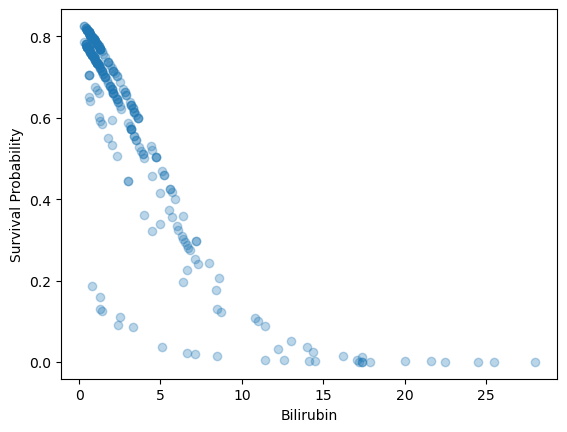

In [107]:
#part 3
df2["pred"] = model2.predict(X)
plt.scatter(df2["Bilirubin"], df2["pred"], alpha=0.3)
plt.xlabel("Bilirubin")
plt.ylabel("Survival Probability")
plt.show()

The survival probability increases as bilirubin decreases. D-penicillamine does not increase survival probability. On average 4.2 percent the drug increases survival.

In [108]:
#part 4
y_pred = (df2["pred"] > 0.5).astype(int)
print(confusion_matrix(y, y_pred))
print(accuracy_score(y, y_pred))

[[ 57  68]
 [ 14 173]]
0.7371794871794872


Accuracy of about 74 percent

#### Part 5

The logistic regression performs better because it keeps the predictiion between 0 and 1. The linear models has values outside of those boundaries which are misleading.

In [109]:
# part 6
X = pd.get_dummies(df2[["Edema", "Bilirubin"]], drop_first=True)
X = X.astype(float)
X = sm.add_constant(X)
y_stage = df2["Stage"].astype(int)
model_stage = sm.MNLogit(y_stage, X).fit()
print(model_stage.summary())

         Current function value: 1.152675
         Iterations: 35
                          MNLogit Regression Results                          
Dep. Variable:                  Stage   No. Observations:                  312
Model:                        MNLogit   Df Residuals:                      300
Method:                           MLE   Df Model:                            9
Date:                Tue, 28 Apr 2026   Pseudo R-squ.:                 0.05331
Time:                        23:32:51   Log-Likelihood:                -359.63
converged:                      False   LL-Null:                       -379.89
Covariance Type:            nonrobust   LLR p-value:                 6.164e-06
   Stage=2       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6172      0.451      1.369      0.171      -0.266       1.501
Bilirubin      0.5294      0.315      1.679      0.093      -0.08

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


The hard classifier does not predict every class, only the 3 and 4 stages. The predicted probabilites assign probabilities to all the stages. Probability is more useful.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

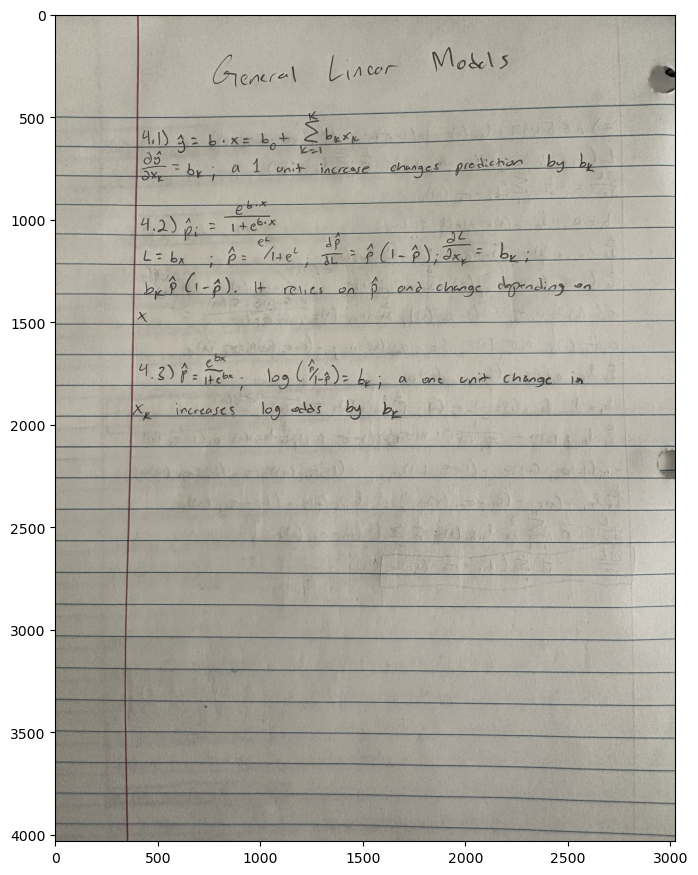

In [110]:
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

img = Image.open("IMG_3698.png")
img = ImageOps.exif_transpose(img)
plt.figure(figsize=(8, 12))
plt.imshow(img)
plt.show()